In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

import clickhouse_connect

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Make sure wide DataFrames don't wrap
pd.set_option("display.width", None)

# Show the full content of each column (no '...')
pd.set_option("display.max_colwidth", None)

In [2]:
client = clickhouse_connect.get_client(
    host='yaujulxk39.eastus2.azure.clickhouse.cloud',      # or server IP
    port=8443,             # HTTP port (default)
    username='default',
    password='~gZjRLjjOJh1i',
    database='Competitive_Analysis'
)

In [3]:
# ---- Query ----
df_hum_hist = client.query_df("""
    SELECT *
    FROM Competitive_Analysis.DRGHistoricalReviewInformation
    WHERE Client = 'Hum'
""")
df_hum_hist.shape

(77169, 291)

In [4]:
# -------------------------------------------------
# Initial shape of the dataset
# -------------------------------------------------
df_hum = df_hum_hist.copy()

print(df_hum.shape)  

df_hum = df_hum[df_hum['InitialDenialType'] == 'Substantive']
print(df_hum.shape) 

# -------------------------------------------------
# Identify valid Group_Type values
# -------------------------------------------------

group_type_unique = df_hum['Group_Type'].dropna().unique()
print(group_type_unique) 

# -------------------------------------------------
# Filter dataset to only valid Group_Type rows
# Use .copy() to avoid SettingWithCopyWarning
# -------------------------------------------------
df_hum_group_type = df_hum[df_hum['Group_Type'].isin(group_type_unique)].copy()
print(df_hum_group_type.shape) 

# -------------------------------------------------
# Calculate ADRG length
# -------------------------------------------------
df_hum_group_type.loc[:, 'len_adrg'] = (
    df_hum_group_type['ADRG'].astype(str).str.len()
)

print(df_hum_group_type['len_adrg'].value_counts())
print(df_hum_group_type['Group_Type'].value_counts())

# -------------------------------------------------
# Remove invalid DRG / Group_Type combinations
#   1) Group_Type = '01' and ADRG length = 4
#   2) Group_Type = '10' and ADRG length = 3
# -------------------------------------------------
mask_remove = (
    ((df_hum_group_type['Group_Type'] == '01') & (df_hum_group_type['len_adrg'] == 4)) |
    ((df_hum_group_type['Group_Type'] == '10') & (df_hum_group_type['len_adrg'] == 3))
)

df_hum_drg_rem = df_hum_group_type.loc[~mask_remove].copy()
print(df_hum_drg_rem.shape)

# -------------------------------------------------
# Create a copy of InitialDeterminationDate
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = (
    df_hum_drg_rem['InitialDeterminationDate']
)

print(
    df_hum_drg_rem['Control_ID']
    .value_counts()
    .sort_values(ascending=False)
    .head()
)

# -------------------------------------------------
# Convert date column to datetime
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = pd.to_datetime(
    df_hum_drg_rem['InitialDeterminationDate_copy'],
    errors='coerce'
)

# -------------------------------------------------
# Keep latest record per Control_ID
# -------------------------------------------------
df_sorted = df_hum_drg_rem.sort_values(
    'InitialDeterminationDate_copy',
    ascending=False
)

df_hum_latest = df_sorted.drop_duplicates(
    subset='Control_ID',
    keep='first'
).copy()

print(df_hum_latest.shape)

# -------------------------------------------------
# Normalize string columns
# -------------------------------------------------
df_hum_latest.loc[:, 'ADRG'] = (
    df_hum_latest['ADRG'].astype(str).str.strip()
)

df_hum_latest.loc[:, 'PRIM_DX'] = (
    df_hum_latest['PRIM_DX'].astype(str).str.strip().str.upper()
)

df_hum_latest.loc[:, 'InitialDeterminationStatus'] = (
    df_hum_latest['InitialDeterminationStatus']
    .astype(str)
    .str.strip()
    .str.upper()
)

# -------------------------------------------------
# Clean numeric fields
# -------------------------------------------------
df_hum_latest.loc[:, 'IDSavings'] = (
    pd.to_numeric(df_hum_latest['IDSavings'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'LOS'] = (
    pd.to_numeric(df_hum_latest['LOS'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'AGE'] = (
    pd.to_numeric(df_hum_latest['AGE'], errors='coerce')
)

# -------------------------------------------------
# Validate AGE values
# -------------------------------------------------
max_age = df_hum_latest['AGE'].max()

df_hum_latest = df_hum_latest[(
    df_hum_latest['AGE'].between(0, max_age))
].copy()
df_hum_latest.loc[:, 'AGE'] = df_hum_latest['AGE'].astype('Int64')
print(df_hum_latest.shape)

# -------------------------------------------------
# Validate LOS values
# -------------------------------------------------
df_hum_latest.loc[:, 'LOS'] = (
    df_hum_latest['LOS'].astype('Int64')
)

df_hum_latest = df_hum_latest[(df_hum_latest['LOS'] >= 0)].copy()
print(df_hum_latest.shape)

# -------------------------------------------------
# Remove extreme savings outliers
# -------------------------------------------------
df_hum_latest = df_hum_latest[
    df_hum_latest['IDSavings'] < 650000
].reset_index(drop=True)

print(df_hum_latest.shape)

# Date only
df_hum_latest['InitialDeterminationDate_date'] = (
    df_hum_latest['InitialDeterminationDate'].dt.date
)

# Year
df_hum_latest['InitialDetermination_Year'] = (
    df_hum_latest['InitialDeterminationDate'].dt.year
)

df_hum_latest["InitialDeterminationDate_date"] = pd.to_datetime(
    df_hum_latest["InitialDeterminationDate_date"],
    errors="coerce"   # handles bad / empty values safely
)


df_hum_latest['Target'] = (
    df_hum_latest['InitialDeterminationStatus']
    .str.strip()
    .str.upper()
    .map({
        'APPROVED': 0,
        'DENIED': 1
    })
)


df_hum_latest.shape

df_hum_ms_drg = df_hum_latest[df_hum_latest['Group_Type']=='01']
print(df_hum_ms_drg.shape)

df_hum_ms_drg['len_adrg'].value_counts()

(77169, 291)
(77169, 291)
<StringArray>
['01', '10']
Length: 2, dtype: string
(77165, 291)
len_adrg
3    76011
4     1154
Name: count, dtype: int64
Group_Type
01    76010
10     1155
Name: count, dtype: Int64
(77152, 292)
Control_ID
HUPTMR-70829    2
HUPRMR-9936     2
HUPTMR-64547    2
HUPTMR-71126    2
HUPTMR-71867    2
Name: count, dtype: Int64
(77145, 293)
(77144, 293)
(77142, 293)
(77142, 293)
(75994, 296)


len_adrg
3    75994
Name: count, dtype: int64

# Model - 20260331

In [ ]:
# ============================================================
# 🔥 CLAIM DENIAL PIPELINE - B-PART REMOVED (PRODUCTION READY)
# ============================================================

import pandas as pd
import numpy as np
import torch
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------
# CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMB_DIM = 768
QUERY = torch.randn(EMB_DIM, device=DEVICE)

# ============================================================
# 1. LOAD DATA
# ============================================================
df = df_hum_ms_drg.copy()
df = df.rename(columns={'AGE':'Age'})

# ============================================================
# 2. CREATE DX / PX LISTS
# ============================================================
adx_cols = [f"A_DX{i}" for i in range(2,26)]
apx_cols = [f"A_PX{i}" for i in range(1,26)]
df["A_DX_List"] = df[adx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)
df["A_PX_List"] = df[apx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)

# ============================================================
# 3. SPLIT DX TYPES
# ============================================================
def split_dx_types(dx_string):
    if pd.isna(dx_string) or dx_string=="": 
        return pd.Series(["","","",0,0,0])
    dx_list = [x.strip() for x in dx_string.split(",")]
    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc  = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    gen = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]
    return pd.Series([",".join(sorted(mcc)),",".join(sorted(cc)),",".join(sorted(gen)),
                      len(mcc),len(cc),len(gen)])

df[["A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set",
    "A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"]] = df["A_DX_List"].apply(split_dx_types)

df = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]

# ============================================================
# 4. LOAD EMBEDDINGS
# ============================================================
with open(r"C:\Arun_MIX\Model\20260326_embeddings.pkl","rb") as f:
    data = pickle.load(f)

drg_dict, icd_dict, proc_dict = data["drg_dict"], data["icd_dict"], data["proc_dict"]

def get_single_emb(code, emb_dict):
    if pd.isna(code): return np.zeros(EMB_DIM, dtype=np.float32)
    emb = emb_dict.get(str(code).strip())
    if emb is None or len(emb)!=EMB_DIM: return np.zeros(EMB_DIM, dtype=np.float32)
    return np.array(emb, dtype=np.float32)

df["DRG_EMB"] = df["ADRG"].apply(lambda x: get_single_emb(x, drg_dict))
df["PRIM_DX_EMB"] = df["PRIM_DX"].apply(lambda x: get_single_emb(x, icd_dict))

def map_icd_embeddings(code_str):
    if pd.isna(code_str) or code_str=="": return []
    codes = code_str.split(",")
    return [np.array(icd_dict[c.strip()],dtype=np.float32) for c in codes 
            if c.strip() in icd_dict and len(icd_dict[c.strip()])==EMB_DIM]

def map_proc_embeddings(code_str):
    if pd.isna(code_str) or code_str=="": return []
    codes = code_str.split(",")
    return [np.array(proc_dict[c.strip()],dtype=np.float32) for c in codes 
            if c.strip() in proc_dict and len(proc_dict[c.strip()])==EMB_DIM]

df["MCC_EMB_LIST"] = df["A_DX_MCC_Set"].apply(map_icd_embeddings)
df["CC_EMB_LIST"] = df["A_DX_CC_Set"].apply(map_icd_embeddings)
df["GENERAL_EMB_LIST"] = df["A_DX_General_Set"].apply(map_icd_embeddings)
df["PROC_EMB_LIST"] = df["A_PX_List"].apply(map_proc_embeddings)

df = df[~df["DRG_EMB"].isnull()]

# ============================================================
# 5. ATTENTION POOLING
# ============================================================
def attention_pooling(col):
    zero_vec = np.zeros(EMB_DIM, dtype=np.float32)
    pooled = []
    for lst in col:
        if not isinstance(lst, list) or len(lst)==0:
            pooled.append(zero_vec)
            continue
        lst = [x for x in lst if isinstance(x,np.ndarray) and x.shape==(EMB_DIM,)]
        if len(lst)==0: pooled.append(zero_vec); continue
        if len(lst)==1: pooled.append(lst[0]); continue
        X = torch.tensor(np.stack(lst), dtype=torch.float32, device=DEVICE)
        attn = torch.softmax((QUERY.unsqueeze(0) @ X.T)/np.sqrt(EMB_DIM), dim=-1)
        vec = (attn @ X).squeeze(0).cpu().numpy()
        pooled.append(vec.astype(np.float32) if vec.shape==(EMB_DIM,) else zero_vec)
    return pd.Series(pooled, index=col.index)

df["MCC_EMB_POOLED"] = attention_pooling(df["MCC_EMB_LIST"])
df["CC_EMB_POOLED"] = attention_pooling(df["CC_EMB_LIST"])
df["GENERAL_EMB_POOLED"] = attention_pooling(df["GENERAL_EMB_LIST"])
df["PROC_EMB_POOLED"] = attention_pooling(df["PROC_EMB_LIST"])

# ============================================================
# 6. TRAIN / VALID SPLIT
# ============================================================
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Target"])

# ============================================================
# 7. SCALING
# ============================================================
num_cols = ["Payments","LOS","Age"]
scaler = StandardScaler()
train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
valid_df.loc[:,num_cols] = scaler.transform(valid_df[num_cols])

# ============================================================
# 8. TARGET ENCODING
# ============================================================
def target_encode(train, valid, col, alpha=20):
    mean = train["Target"].mean()
    stats = train.groupby(col)["Target"].agg(["mean","count"])
    smooth = (stats["mean"]*stats["count"] + mean*alpha)/(stats["count"]+alpha)
    train[col+"_enc"] = train[col].map(smooth)
    valid[col+"_enc"] = valid[col].map(smooth)
    valid[col+"_enc"] = valid[col+"_enc"].fillna(mean)
    return train, valid

train_df, valid_df = target_encode(train_df, valid_df, "ADRG")
train_df, valid_df = target_encode(train_df, valid_df, "PRIM_DX")

# ============================================================
# 9. CREATE STATS FEATURES
# ============================================================
def create_stats(train, col):
    temp = train[[col,"Target"]].dropna()
    temp[col] = temp[col].str.split(",")
    temp = temp.explode(col)
    temp[col] = temp[col].str.strip()
    stats = temp.groupby(col)["Target"].agg(["mean","count"])
    stats.columns = ["rate","freq"]
    return stats

def apply_stats(df, stats, col, prefix):
    def calc(x):
        if pd.isna(x): return [0,0]
        vals = [stats.loc[c.strip()] for c in str(x).split(",") if c.strip() in stats.index]
        if not vals: return [0,0]
        rates = [v["rate"] for v in vals]
        freqs = [v["freq"] for v in vals]
        return [np.mean(rates), np.mean(freqs)]
    tmp = df[col].apply(calc)
    df[prefix+"_rate"] = tmp.apply(lambda x: x[0])
    df[prefix+"_freq"] = tmp.apply(lambda x: x[1])
    return df

cols = ["A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set","A_PX_List"]
prefix = ["MCC","CC","GEN","PX"]
stats_store = {}
for c in cols:
    stats_store[c] = create_stats(train_df, c)
for c,p in zip(cols,prefix):
    train_df = apply_stats(train_df, stats_store[c], c, p)
    valid_df = apply_stats(valid_df, stats_store[c], c, p)

# ============================================================
# 10. BUILD FEATURES
# ============================================================
def safe_stack(series):
    return np.stack(series.apply(lambda x: x if isinstance(x,np.ndarray) and x.shape==(EMB_DIM,) 
                                 else np.zeros(EMB_DIM,dtype=np.float32)))

def build_X(df):
    drg = safe_stack(df["DRG_EMB"])
    pdx = safe_stack(df["PRIM_DX_EMB"])
    mcc = safe_stack(df["MCC_EMB_POOLED"])
    cc  = safe_stack(df["CC_EMB_POOLED"])
    gen = safe_stack(df["GENERAL_EMB_POOLED"])
    proc = safe_stack(df["PROC_EMB_POOLED"])
    emb = np.concatenate([drg,pdx,mcc,cc,gen,proc], axis=1)
    counts = df[["A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"]].values
    numeric = df[["Payments","LOS","Age"]].values
    stats = df[["ADRG_enc","PRIM_DX_enc","MCC_rate","MCC_freq","CC_rate","CC_freq",
                "GEN_rate","GEN_freq","PX_rate","PX_freq"]].values
    return np.concatenate([emb, counts, numeric, stats], axis=1)

X_train = build_X(train_df)
X_valid = build_X(valid_df)
y_train = train_df["Target"].values
y_valid = valid_df["Target"].values



C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_12356\218270067.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.21777762 -0.91436749 -0.59089746 ...  0.70298266 -0.10569242
 -0.59089746]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_12356\218270067.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.97673953  1.25928258 -0.97673953 ...  0.59675751  1.09365131
 -0.31421446]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_12356\218270067.py:123: FutureWarning: Setting an item of incompatible dtype is deprecate

# Best Model on Staging model

[LightGBM] [Info] Number of positive: 7300, number of negative: 53495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.781998 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151027
[LightGBM] [Info] Number of data points in the train set: 60795, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120076 -> initscore=-1.991714
[LightGBM] [Info] Start training from score -1.991714


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- STAGE 1 RESULTS ---
[[9679 3695]
 [ 365 1460]]
              precision    recall  f1-score   support

           0       0.96      0.72      0.83     13374
           1       0.28      0.80      0.42      1825

    accuracy                           0.73     15199
   macro avg       0.62      0.76      0.62     15199
weighted avg       0.88      0.73      0.78     15199



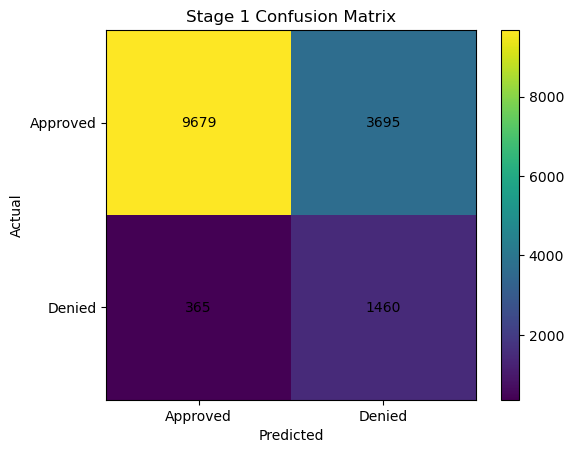

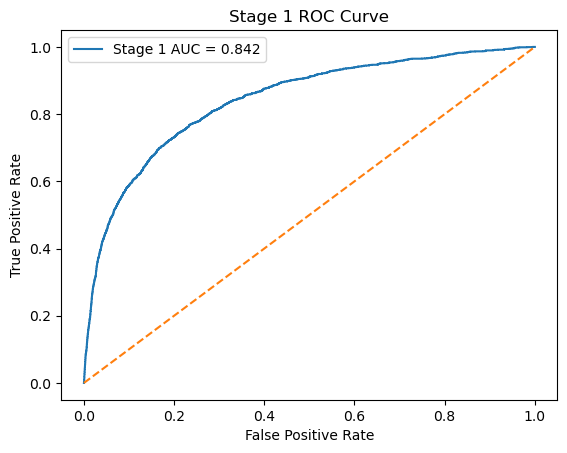

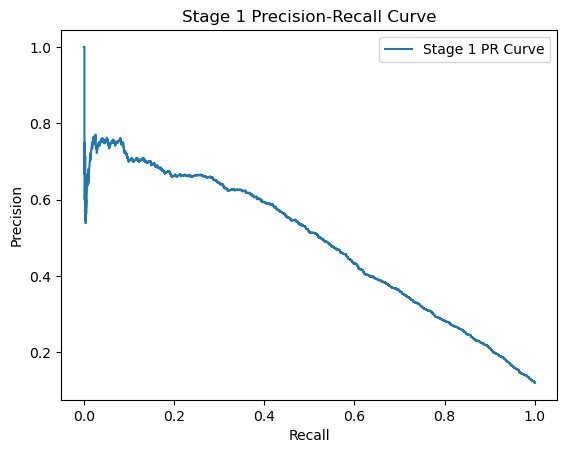

[LightGBM] [Info] Number of positive: 1460, number of negative: 3695
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.272721 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1073376
[LightGBM] [Info] Number of data points in the train set: 5155, number of used features: 4625
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.283220 -> initscore=-0.928544
[LightGBM] [Info] Start training from score -0.928544


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- FINAL RESULTS ---
Stage 1 Passed Cases: 5155
[[13181   193]
 [  476  1349]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13374
           1       0.87      0.74      0.80      1825

    accuracy                           0.96     15199
   macro avg       0.92      0.86      0.89     15199
weighted avg       0.95      0.96      0.95     15199

ROC-AUC: 0.8692718851339033


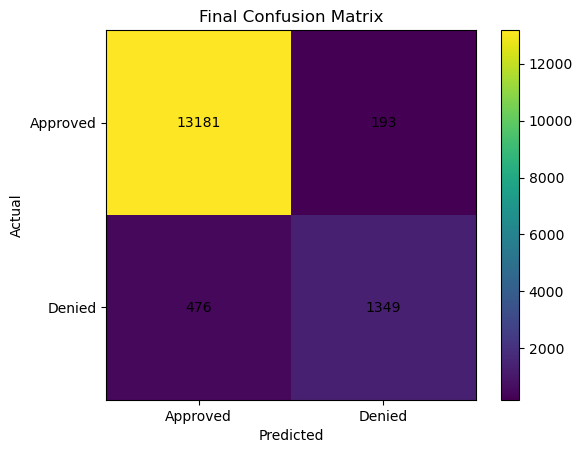

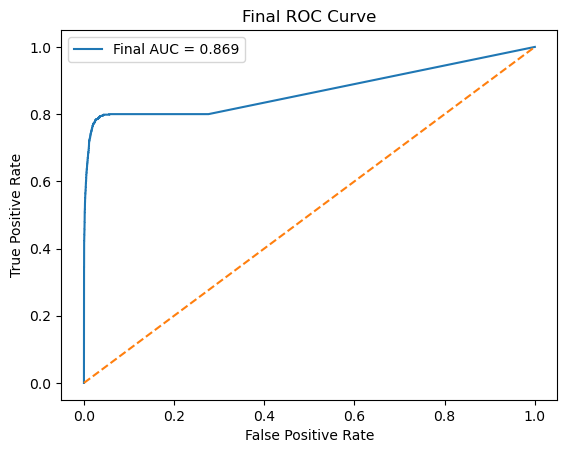

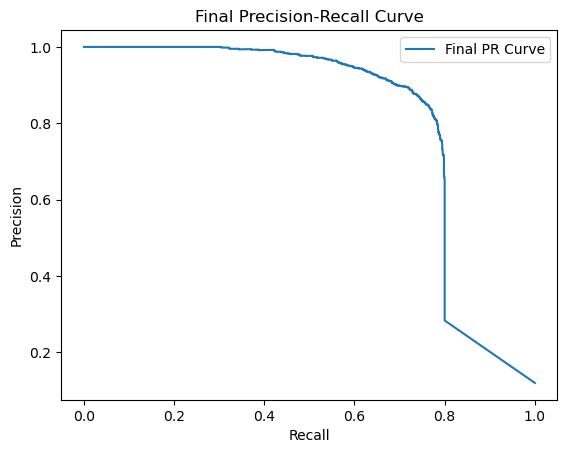

In [6]:
# ============================================================
# 🔥 TWO-STAGE PIPELINE (WITH STAGE 1 + FINAL VISUALS)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

# ============================================================
# 🔥 STAGE 1 → HIGH RECALL MODEL
# ============================================================

stage1_params = {
    "n_estimators": 365,
    "learning_rate": 0.011,
    "num_leaves": 128,
    "max_depth": -1,
    "min_child_samples": 10,
    "subsample": 0.97,
    "colsample_bytree": 0.75,
    "reg_alpha": 0,
    "reg_lambda": 0,
    "scale_pos_weight": 3.5,
    "random_state": 42,
    "n_jobs": -1
}

stage1_model = LGBMClassifier(**stage1_params)
stage1_model.fit(X_train, y_train)

# Predictions
probs_stage1 = stage1_model.predict_proba(X_valid)[:, 1]

# Threshold (recall priority)
precision1, recall1, thresholds1 = precision_recall_curve(y_valid, probs_stage1)
recall_target = 0.80
idx1 = np.where(recall1 >= recall_target)[0][-1]
stage1_threshold = thresholds1[idx1]

stage1_preds = (probs_stage1 >= stage1_threshold).astype(int)
stage1_mask = stage1_preds.astype(bool)

# ============================================================
# 📊 STAGE 1 METRICS
# ============================================================

print("\n--- STAGE 1 RESULTS ---")
cm1 = confusion_matrix(y_valid, stage1_preds)
print(cm1)
print(classification_report(y_valid, stage1_preds))

# ============================================================
# 📊 STAGE 1 CONFUSION MATRIX GRAPH
# ============================================================

plt.figure()
plt.imshow(cm1)
plt.title("Stage 1 Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Approved","Denied"])
plt.yticks([0,1], ["Approved","Denied"])

for i in range(cm1.shape[0]):
    for j in range(cm1.shape[1]):
        plt.text(j, i, cm1[i,j], ha="center", va="center")

plt.show()

# ============================================================
# 📈 STAGE 1 ROC CURVE
# ============================================================

fpr1, tpr1, _ = roc_curve(y_valid, probs_stage1)
auc1 = roc_auc_score(y_valid, probs_stage1)

plt.figure()
plt.plot(fpr1, tpr1, label=f"Stage 1 AUC = {auc1:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage 1 ROC Curve")
plt.legend()
plt.show()


# ============================================================
# 📈 STAGE 1 PRECISION-RECALL CURVE
# ============================================================

precision1, recall1, _ = precision_recall_curve(y_valid, probs_stage1)

plt.figure()
plt.plot(recall1, precision1, label="Stage 1 PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Stage 1 Precision-Recall Curve")
plt.legend()
plt.show()


# ============================================================
# 🔥 PREPARE STAGE 2 DATA
# ============================================================

X_stage2 = X_valid[stage1_mask].copy()
y_stage2 = y_valid[stage1_mask]

X_stage2 = np.hstack([
    X_stage2,
    probs_stage1[stage1_mask].reshape(-1, 1)
])

# ============================================================
# 🔥 STAGE 2 → PRECISION CONTROL
# ============================================================

stage2_params = {
    "n_estimators": 365,
    "learning_rate": 0.011,
    "num_leaves": 32,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.97,
    "colsample_bytree": 0.75,
    "reg_alpha": 0,
    "reg_lambda": 0,
    "scale_pos_weight": 2.0,
    "random_state": 42,
    "n_jobs": -1
}

stage2_model = LGBMClassifier(**stage2_params)
stage2_model.fit(X_stage2, y_stage2)

# Threshold tuning (F1)
probs_stage2_train = stage2_model.predict_proba(X_stage2)[:, 1]

precision2, recall2, thresholds2 = precision_recall_curve(y_stage2, probs_stage2_train)
f1_scores = 2 * (precision2 * recall2) / (precision2 + recall2 + 1e-8)
best_idx2 = f1_scores.argmax()
stage2_threshold = thresholds2[best_idx2]

# ============================================================
# 🔥 FINAL PREDICTIONS
# ============================================================

final_preds = np.zeros(len(X_valid))
final_probs = np.zeros(len(X_valid))

X_stage2_full = X_valid[stage1_mask].copy()
X_stage2_full = np.hstack([
    X_stage2_full,
    probs_stage1[stage1_mask].reshape(-1, 1)
])

probs_stage2 = stage2_model.predict_proba(X_stage2_full)[:, 1]
stage2_preds = (probs_stage2 >= stage2_threshold).astype(int)

final_preds[stage1_mask] = stage2_preds
final_probs[stage1_mask] = probs_stage2

# ============================================================
# 📊 FINAL RESULTS
# ============================================================

print("\n--- FINAL RESULTS ---")
print("Stage 1 Passed Cases:", stage1_mask.sum())

cm2 = confusion_matrix(y_valid, final_preds)
print(cm2)
print(classification_report(y_valid, final_preds))
print("ROC-AUC:", roc_auc_score(y_valid, final_probs))

# ============================================================
# 📊 FINAL CONFUSION MATRIX GRAPH
# ============================================================

plt.figure()
plt.imshow(cm2)
plt.title("Final Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Approved","Denied"])
plt.yticks([0,1], ["Approved","Denied"])

for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        plt.text(j, i, cm2[i,j], ha="center", va="center")

plt.show()

# ============================================================
# 📈 FINAL ROC CURVE
# ============================================================

fpr2, tpr2, _ = roc_curve(y_valid, final_probs)
auc2 = roc_auc_score(y_valid, final_probs)

plt.figure()
plt.plot(fpr2, tpr2, label=f"Final AUC = {auc2:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 📈 FINAL PRECISION-RECALL CURVE
# ============================================================

precision2_full, recall2_full, _ = precision_recall_curve(y_valid, final_probs)

plt.figure()
plt.plot(recall2_full, precision2_full, label="Final PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Precision-Recall Curve")
plt.legend()
plt.show()

In [43]:
import pickle

pipeline = {
    "stage1_model": stage1_model,
    "stage2_model": stage2_model,

    "stage1_threshold": stage1_threshold,
    "stage2_threshold": stage2_threshold,

    "scaler": scaler,
    "stats_store": stats_store,

    "drg_dict": drg_dict,
    "icd_dict": icd_dict,
    "proc_dict": proc_dict,

    "adrg_encoding_map": adrg_map,        # ✅ REQUIRED
    "primdx_encoding_map": primdx_map,    # ✅ REQUIRED

    "QUERY": QUERY.cpu().numpy(),         # ✅ IMPORTANT (attention consistency)
    "EMB_DIM": EMB_DIM
}

# ============================================================
# 💾 SAVE
# ============================================================

file_path = "20260331_Two_Stage_Best_full_pipeline.pkl"

with open(file_path, "wb") as f:
    pickle.dump(pipeline, f)

print(f"✅ Full pipeline saved at: {file_path}")

✅ Full pipeline saved at: 20260331_Two_Stage_Best_full_pipeline.pkl


# Unseen Data Prediction

## Data from iternation with result underprocessing value taken from bank

In [12]:
df_up = pd.read_excel(r"C:\Users\arunkumara\Downloads\Model_Test_COntrol_IDs.xlsx")
df_up.shape

(3487, 1)

In [35]:
df_hum_bank = client.query_df("""
    SELECT 
        CONTROL_ID,
        PAYMENTS,
        LOS,
        Age,
        ADRG,
        PRIM_DX,
        A_DX2, A_DX3, A_DX4, A_DX5, A_DX6, A_DX7, A_DX8, A_DX9, A_DX10,
        A_DX11, A_DX12, A_DX13, A_DX14, A_DX15, A_DX16, A_DX17, A_DX18,
        A_DX19, A_DX20, A_DX21, A_DX22, A_DX23, A_DX24, A_DX25,
        A_PX1, A_PX2, A_PX3, A_PX4, A_PX5, A_PX6, A_PX7, A_PX8, A_PX9, A_PX10,
        A_PX11, A_PX12, A_PX13, A_PX14, A_PX15, A_PX16, A_PX17, A_PX18,
        A_PX19, A_PX20, A_PX21, A_PX22, A_PX23, A_PX24, A_PX25
    FROM HumanaBankData
    WHERE CONTROL_ID IS NOT NULL
""")

df_hum_bank.shape

(67426, 55)

In [36]:
df_hum_unseen = df_hum_bank[df_hum_bank['CONTROL_ID'].isin(df_up['CONTROL_ID'])]
df_hum_unseen.shape

(4054, 55)

In [37]:
df_hum_unseen = df_hum_unseen.drop_duplicates()
df_hum_unseen.shape

(3487, 55)

In [40]:
df_hum_unseen.loc[:, 'len_adrg'] = (
    df_hum_unseen['ADRG'].astype(str).str.len()
)

df_hum_unseen['len_adrg'].value_counts()

len_adrg
3    3392
4      95
Name: count, dtype: int64

In [38]:
df_hum_unseen.head(1)

,CONTROL_ID,PAYMENTS,LOS,Age,ADRG,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25
1,HUPTHMR-515,301258.78,83,72,003,T2131XA - CC,T3131 - MCC,R578 - MCC,J9621 - MCC,J9602 - MCC,J95851 - CC,D61818 - CC,E46 - CC,E873 - CC,T2132XA - CC,E870 - CC,J984,T2020XA,T23342A - CC,T2134XA - CC,T23302A - CC,T24311A - CC,T22392A - CC,T22391A - CC,T24312A - CC,T2025XA,T2027XA,T20212A,T20211A,I358,0HR5X72,5A1955Z,0B113F4,0JB60ZZ,0HR5X74,0X6M0Z0,0JB70ZZ,0HR6XK3,0JB80ZZ,0HR7XK3,0HR5XK3,0JBM0ZZ,0JNK0ZZ,0JNF0ZZ,0JNH0ZZ,0HRJXK3,0JBL0ZZ,0HRHXK3,0JBM0ZZ,0HRGX74,0HRJX74,0JBL0ZZ,0HR7X72,0HRHX72,0HRHX74


In [44]:
import pickle
import numpy as np
import torch

# Load pipeline
with open("20260331_Two_Stage_Best_full_pipeline.pkl", "rb") as f:
    pipe = pickle.load(f)

# Models
stage1_model = pipe["stage1_model"]
stage2_model = pipe["stage2_model"]

# Thresholds
stage1_threshold = pipe["stage1_threshold"]
stage2_threshold = pipe["stage2_threshold"]

# Preprocessing
scaler = pipe["scaler"]
stats_store = pipe["stats_store"]

# Embeddings
drg_dict = pipe["drg_dict"]
icd_dict = pipe["icd_dict"]
proc_dict = pipe["proc_dict"]

# Encoding maps
adrg_map = pipe["adrg_encoding_map"]
primdx_map = pipe["primdx_encoding_map"]

# Attention
EMB_DIM = pipe["EMB_DIM"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
QUERY = torch.tensor(pipe["QUERY"], device=DEVICE)

# Global mean (fallback)
global_mean = np.mean(list(adrg_map.values()))

In [45]:
def predict_claims(df):

    df = df.copy().reset_index(drop=True)

    # ============================================================
    # 🔥 BASIC CLEANING
    # ============================================================

    df.rename(columns={"PAYMENTS": "Payments"}, inplace=True)

    df["PRIM_DX"] = df["PRIM_DX"].astype(str).str.split(" - ").str[0].str.strip()
    df["ADRG"] = df["ADRG"].astype(str).str.strip()

    # ============================================================
    # 🔥 ADRG VALID MASK (DO NOT DROP ROWS)
    # ============================================================

    valid_mask = df["ADRG"].str.len() == 3

    final_preds = np.zeros(len(df))
    final_probs = np.zeros(len(df))

    # Work only on valid rows
    df_valid = df[valid_mask].copy()

    if len(df_valid) == 0:
        return final_preds, final_probs

    # ============================================================
    # 🔥 TARGET ENCODING
    # ============================================================

    df_valid["ADRG_enc"] = df_valid["ADRG"].map(adrg_map).fillna(global_mean)
    df_valid["PRIM_DX_enc"] = df_valid["PRIM_DX"].map(primdx_map).fillna(global_mean)

    # ============================================================
    # 🔥 CREATE LISTS
    # ============================================================

    adx_cols = [f"A_DX{i}" for i in range(2,26)]
    apx_cols = [f"A_PX{i}" for i in range(1,26)]

    df_valid["A_DX_List"] = df_valid[adx_cols].apply(
        lambda x: ",".join([str(i) for i in x if pd.notna(i)]), axis=1
    )
    df_valid["A_PX_List"] = df_valid[apx_cols].apply(
        lambda x: ",".join([str(i) for i in x if pd.notna(i)]), axis=1
    )

    # ============================================================
    # 🔥 SPLIT DX TYPES
    # ============================================================

    def split_dx_types(dx_string):
        if pd.isna(dx_string) or dx_string == "":
            return pd.Series(["","","",0,0,0])

        dx_list = [x.strip() for x in dx_string.split(",")]

        mcc = [x for x in dx_list if x.endswith("MCC")]
        cc  = [x for x in dx_list if x.endswith("CC")]
        gen = [x for x in dx_list if not (x.endswith("MCC") or x.endswith("CC"))]

        return pd.Series([
            ",".join(mcc),
            ",".join(cc),
            ",".join(gen),
            len(mcc),
            len(cc),
            len(gen)
        ])

    df_valid[[
        "A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set",
        "A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"
    ]] = df_valid["A_DX_List"].apply(split_dx_types)

    # ============================================================
    # 🔥 EMBEDDINGS
    # ============================================================

    df_valid["DRG_EMB"] = df_valid["ADRG"].apply(lambda x: get_single_emb(x, drg_dict))
    df_valid["PRIM_DX_EMB"] = df_valid["PRIM_DX"].apply(lambda x: get_single_emb(x, icd_dict))

    df_valid["MCC_EMB_LIST"] = df_valid["A_DX_MCC_Set"].apply(map_icd_embeddings)
    df_valid["CC_EMB_LIST"] = df_valid["A_DX_CC_Set"].apply(map_icd_embeddings)
    df_valid["GENERAL_EMB_LIST"] = df_valid["A_DX_General_Set"].apply(map_icd_embeddings)
    df_valid["PROC_EMB_LIST"] = df_valid["A_PX_List"].apply(map_proc_embeddings)

    # Attention pooling (must preserve index)
    df_valid["MCC_EMB_POOLED"] = attention_pooling(df_valid["MCC_EMB_LIST"])
    df_valid["CC_EMB_POOLED"] = attention_pooling(df_valid["CC_EMB_LIST"])
    df_valid["GENERAL_EMB_POOLED"] = attention_pooling(df_valid["GENERAL_EMB_LIST"])
    df_valid["PROC_EMB_POOLED"] = attention_pooling(df_valid["PROC_EMB_LIST"])

    # ============================================================
    # 🔥 SCALING
    # ============================================================

    df_valid[["Payments","LOS","Age"]] = scaler.transform(
        df_valid[["Payments","LOS","Age"]]
    )

    # ============================================================
    # 🔥 STATS FEATURES
    # ============================================================

    df_valid = apply_stats(df_valid, stats_store["A_DX_MCC_Set"], "A_DX_MCC_Set", "MCC")
    df_valid = apply_stats(df_valid, stats_store["A_DX_CC_Set"], "A_DX_CC_Set", "CC")
    df_valid = apply_stats(df_valid, stats_store["A_DX_General_Set"], "A_DX_General_Set", "GEN")
    df_valid = apply_stats(df_valid, stats_store["A_PX_List"], "A_PX_List", "PX")

    # ============================================================
    # 🔥 BUILD FEATURES
    # ============================================================

    X = np.concatenate([
        safe_stack(df_valid["DRG_EMB"]),
        safe_stack(df_valid["PRIM_DX_EMB"]),
        safe_stack(df_valid["MCC_EMB_POOLED"]),
        safe_stack(df_valid["CC_EMB_POOLED"]),
        safe_stack(df_valid["GENERAL_EMB_POOLED"]),
        safe_stack(df_valid["PROC_EMB_POOLED"]),
        df_valid[["A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"]].values,
        df_valid[["Payments","LOS","Age"]].values,
        df_valid[[
            "ADRG_enc","PRIM_DX_enc",
            "MCC_rate","MCC_freq",
            "CC_rate","CC_freq",
            "GEN_rate","GEN_freq",
            "PX_rate","PX_freq"
        ]].values
    ], axis=1)

    # ============================================================
    # 🔥 TWO-STAGE PREDICTION
    # ============================================================

    probs_stage1 = stage1_model.predict_proba(X)[:, 1]
    stage1_mask = probs_stage1 >= stage1_threshold

    preds_valid = np.zeros(len(df_valid))
    probs_valid = np.zeros(len(df_valid))

    if stage1_mask.sum() > 0:
        X2 = X[stage1_mask]
        X2 = np.hstack([X2, probs_stage1[stage1_mask].reshape(-1,1)])

        probs_stage2 = stage2_model.predict_proba(X2)[:, 1]
        preds_stage2 = (probs_stage2 >= stage2_threshold).astype(int)

        preds_valid[stage1_mask] = preds_stage2
        probs_valid[stage1_mask] = probs_stage2

    # ============================================================
    # 🔥 MAP BACK TO ORIGINAL DF
    # ============================================================

    final_preds[valid_mask] = preds_valid
    final_probs[valid_mask] = probs_valid

    return final_preds, final_probs

In [46]:
preds, probs = predict_claims(df_hum_unseen)

df_hum_unseen["Prediction"] = preds
df_hum_unseen["Risk_Score"] = probs

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [50]:
df_hum_unseen['Prediction'].value_counts()

Prediction
0.0    2941
1.0     546
Name: count, dtype: int64

In [51]:
df_hum_unseen["Prediction_Label"] = df_hum_unseen["Prediction"].map({
    0.0: "Approved",
    1.0: "Denied"
})

In [53]:
df_hum_unseen.to_excel("20260331_Two_Stage_model_unseen_bank_prediction.xlsx",index=False)


In [52]:
df_hum_unseen.tail(10)

,CONTROL_ID,PAYMENTS,LOS,Age,ADRG,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,len_adrg,Prediction,Risk_Score,Prediction_Label
67182,HUPTHMR-2665,26932.61,24,74,492,S82852A,I5021,J690,J9601,F339,I484,F0393,E870,I110,E782,S92002A,I480,E538,R1310,Z9181,Z7901,Z950,E876,E559,I959,<NA>,<NA>,<NA>,<NA>,<NA>,0SGG04Z,5A0935A,5A0935Z,5A09357,0DH63UZ,BD12YZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.000000,Approved
67190,HUPRMR-3761,14193.59,9,90,281,I2119,R64,Z681,I10,E785,I480,I2510,E039,Z950,Z741,Z8249,Z7982,Z955,Z79890,I495,H409,H548,R5381,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.144168,Approved
67294,HUPTHMR-2628,75908.86,22,69,444,K8031,A4151,R6521,U071,G928,I2699,E43,K264,K7210,E1165,D638,E669,I10,Z95828,I8510,K766,R188,D6859,E871,I4710,D62,K7460,Z794,K744,<NA>,0F798DZ,0W9G3ZZ,0FC98ZZ,0D768DZ,02HV33Z,B548ZZA,30233N1,3E043XZ,<NA>,<NA>,<NA>,<NA>,BD15YZZ,BF101ZZ,30233K1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.000000,Approved
67295,HUPTHMR-2646,28609.45,13,60,917,T402X1A,E43,Z5901,Z66,Z515,J9601,M96A4,I468,G931,K7040,D61818,S270XXA,R7881,D6959,B9561,F1120,F1010,E8720,Z681,N179,I2489,B1920,G9389,G253,F419,5A1955Z,02HV33Z,0W9930Z,4A10X4Z,3E0G76Z,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.000000,Approved
67310,HUPTMR-69184,11925.19,4,74,190,J441 - CC,E43 - MCC,I5032 - CC,S2242XA - CC,S72401A - CC,Z681 - CC,E871 - CC,I110,I2510,I4891,M069,I2720,F17210,Z9981,M6284,E559,I350,R001,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.000000,Approved
67345,HUPTMR-69691,15519.84,9,74,180,C3492,I214,I63541,I3139,C771,C7931,D509,F17210,C7951,I2720,J449,I110,I340,I428,I5022,I808,E785,I480,I2510,Z7982,Z800,Z808,<NA>,<NA>,<NA>,0B9J8ZX,4A023N8,B2111ZZ,B2151ZZ,4A033BC,0DB28ZX,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,07D78ZX,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.000000,Approved
67347,HUPTMR-69538,37989.17,9,51,474,T8781,N186,E1052,E8722,D6862,I120,Z9483,M86172,Z992,B964,D539,N2581,E10628,E1022,E10319,E876,E785,I4891,Z7901,Z86718,Z8616,Z8611,Z7902,Z7952,<NA>,0Y6N0Z9,0Y6N0ZB,0Y6N0ZC,0Y6N0ZD,0Y6N0ZF,047U3ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,04CU3ZZ,5A1D70Z,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.000000,Approved
67377,HUPTMR-70466,21553.46,5,70,628,E1169,A419,I5043,M86071,E8721,E8720,I130,E1152,I96,L03115,D631,K7460,E11621,L97519,I2510,N400,K219,E1122,M21621,B182,N189,I252,Z951,Z7984,Z7982,0QBN0ZZ,0L8N3ZZ,0HRMXK3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.311818,Approved
67391,HUPTMR-68345,8272.03,19,46,374,C20,E43,Z515,K652,R180,D701,C7B8,E8720,R6510,D709,C787,C7A8,D849,J90,D509,R591,K6289,T451X5A,T402X5A,D75839,G893,K5903,Z6824,Z86711,<NA>,0W9G3ZZ,3E04305,30233N1,3E0R3BZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.000000,Approved
67392,HUPTMR-68715,8606.55,16,82,193,J189,A4159,I5023,I4821,J440,J441,E870,E785,D509,I2510,I340,M4800,F32A,N1831,R7989,I255,I1310,N400,Z95810,R0689,Z781,Z7901,Z7982,Z79899,<NA>,<NA>,0DBK8ZX,0DBM8ZX,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,0.0,0.219828,Approved


# Best Model from 100 Iternation

See the code 20230330 

In [ ]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=365,
    learning_rate=0.011,
    num_leaves=64,           # increase leaves slightly
    max_depth=-1,            # remove depth restriction temporarily
    min_child_samples=20,    # lower to allow splits
    subsample=0.97,
    colsample_bytree=0.75,
    reg_alpha=0,
    reg_lambda=0,
    scale_pos_weight=2.97
)

model.fit(X_train, y_train)

# Predict probabilities first
y_pred_prob = model.predict_proba(X_valid)[:, 1]

# Compute precision-recall curve
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score

precision, recall, thresholds = precision_recall_curve(y_valid, y_pred_prob)

# Find threshold that maximizes F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # avoid division by zero
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print("Best threshold (F1 max):", best_threshold)

# Apply threshold
y_pred = (y_pred_prob >= best_threshold).astype(int)

# Evaluate
print(classification_report(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid, y_pred_prob))

[LightGBM] [Info] Number of positive: 7300, number of negative: 53495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.745137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151021
[LightGBM] [Info] Number of data points in the train set: 60795, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120076 -> initscore=-1.991714
[LightGBM] [Info] Start training from score -1.991714


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.94      0.93      0.93     13374
           1       0.51      0.53      0.52      1825

    accuracy                           0.88     15199
   macro avg       0.72      0.73      0.72     15199
weighted avg       0.88      0.88      0.88     15199

ROC AUC: 0.8404767991871367


Recall and prescison on denied was 50% want to improve

# # to increase recall precision use stageing model 

[LightGBM] [Info] Number of positive: 7300, number of negative: 53495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.734199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151021
[LightGBM] [Info] Number of data points in the train set: 60795, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120076 -> initscore=-1.991714
[LightGBM] [Info] Start training from score -1.991714


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


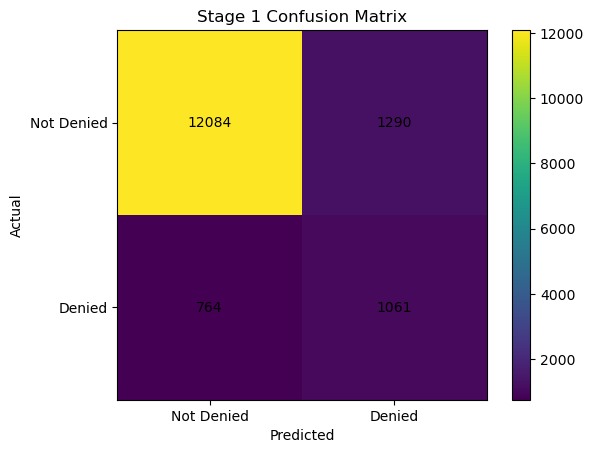

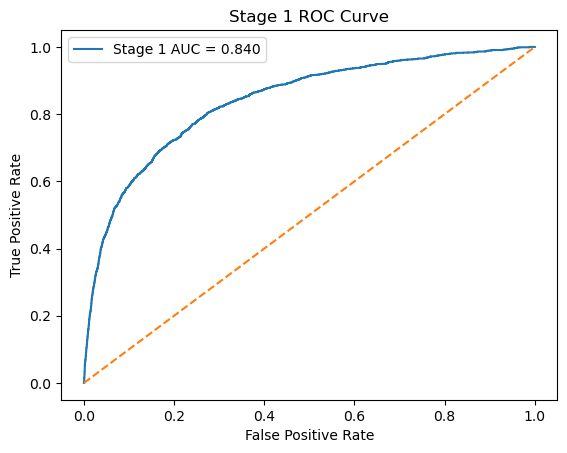

[LightGBM] [Info] Number of positive: 1061, number of negative: 1290
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.348390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 975059
[LightGBM] [Info] Number of data points in the train set: 2351, number of used features: 4625
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.451297 -> initscore=-0.195430
[LightGBM] [Info] Start training from score -0.195430


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


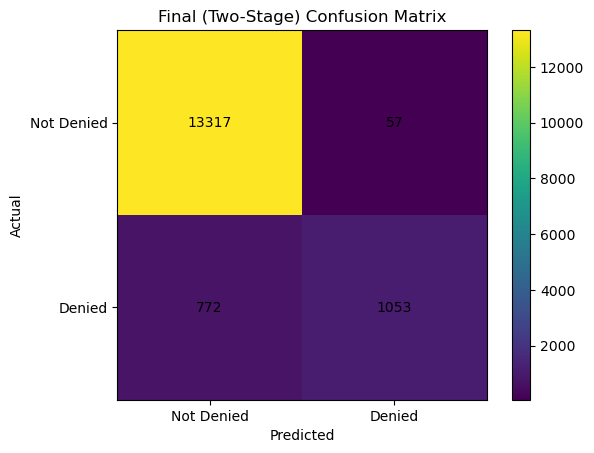

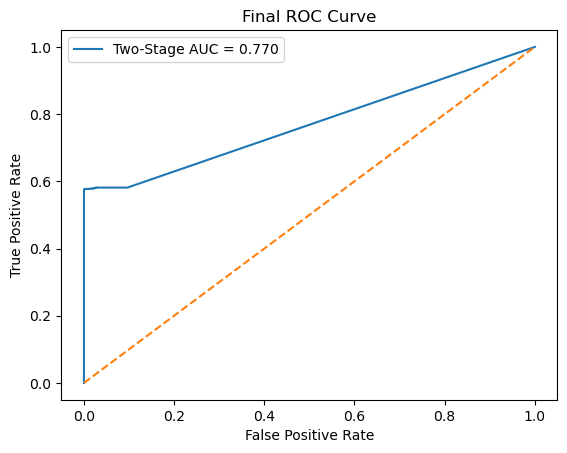

Stage 1 Passed Cases: 2351

FINAL RESULTS:
[[13317    57]
 [  772  1053]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     13374
           1       0.95      0.58      0.72      1825

    accuracy                           0.95     15199
   macro avg       0.95      0.79      0.84     15199
weighted avg       0.95      0.95      0.94     15199

ROC-AUC: 0.7704044650118509


In [ ]:
# ============================================================
# 🔥 FULL TWO-STAGE PIPELINE + UPDATED THRESHOLDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ============================================================
# 🔥 CUSTOM LGBM MODEL (USE FOR BOTH STAGES)
# ============================================================

custom_model_params = {
    "n_estimators": 365,
    "learning_rate": 0.011,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.97,
    "colsample_bytree": 0.75,
    "reg_alpha": 0,
    "reg_lambda": 0,
    "scale_pos_weight": 2.97,
    "random_state": 42,
    "n_jobs": -1
}

# ============================================================
# 🔥 STAGE 1
# ============================================================

stage1_model = LGBMClassifier(**custom_model_params)
stage1_model.fit(X_train, y_train)

# Stage 1 predictions
probs_stage1 = stage1_model.predict_proba(X_valid)[:, 1]
stage1_threshold = 0.40  # updated threshold
stage1_preds = (probs_stage1 > stage1_threshold).astype(int)
stage1_mask = stage1_preds.astype(bool)

# Stage 1 Confusion Matrix
cm1 = confusion_matrix(y_valid, stage1_preds)
plt.figure()
plt.imshow(cm1)
plt.title("Stage 1 Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Denied","Denied"])
plt.yticks([0,1], ["Not Denied","Denied"])
for i in range(cm1.shape[0]):
    for j in range(cm1.shape[1]):
        plt.text(j, i, cm1[i,j], ha="center", va="center")
plt.show()

# Stage 1 ROC Curve
fpr1, tpr1, _ = roc_curve(y_valid, probs_stage1)
auc1 = roc_auc_score(y_valid, probs_stage1)
plt.figure()
plt.plot(fpr1, tpr1, label=f"Stage 1 AUC = {auc1:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage 1 ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 🔥 PREPARE STAGE 2 DATA
# ============================================================

X_stage2 = X_valid[stage1_mask].copy()
y_stage2 = y_valid[stage1_mask]

# Add Stage 1 probabilities as a feature
X_stage2 = np.hstack([
    X_stage2,
    probs_stage1[stage1_mask].reshape(-1,1)
])

# ============================================================
# 🔥 STAGE 2
# ============================================================

stage2_params = custom_model_params.copy()
stage2_params.update({
    "num_leaves": 32,          # simpler tree
    "min_child_samples": 50,   # require more samples to split
    "scale_pos_weight": 2.0    # less aggressive on class 1
})
stage2_model = LGBMClassifier(**stage2_params)
stage2_model.fit(X_stage2, y_stage2)

# ============================================================
# 🔥 FINAL PREDICTIONS (TWO-STAGE)
# ============================================================

final_preds = np.zeros(len(X_valid))
final_probs = np.zeros(len(X_valid))

X_stage2_full = X_valid[stage1_mask].copy()
X_stage2_full = np.hstack([
    X_stage2_full,
    probs_stage1[stage1_mask].reshape(-1,1)
])

probs_stage2 = stage2_model.predict_proba(X_stage2_full)[:, 1]
stage2_threshold = 0.6554356216080027  # updated threshold
stage2_preds = (probs_stage2 > stage2_threshold).astype(int)

final_preds[stage1_mask] = stage2_preds
final_probs[stage1_mask] = probs_stage2

# ============================================================
# 📊 FINAL CONFUSION MATRIX
# ============================================================

cm2 = confusion_matrix(y_valid, final_preds)
plt.figure()
plt.imshow(cm2)
plt.title("Final (Two-Stage) Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Denied","Denied"])
plt.yticks([0,1], ["Not Denied","Denied"])
for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        plt.text(j, i, cm2[i,j], ha="center", va="center")
plt.show()

# ============================================================
# 📈 FINAL ROC CURVE
# ============================================================

fpr2, tpr2, _ = roc_curve(y_valid, final_probs)
auc2 = roc_auc_score(y_valid, final_probs)
plt.figure()
plt.plot(fpr2, tpr2, label=f"Two-Stage AUC = {auc2:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 📊 FINAL METRICS
# ============================================================

print("Stage 1 Passed Cases:", stage1_mask.sum())
print("\nFINAL RESULTS:")
print(confusion_matrix(y_valid, final_preds))
print(classification_report(y_valid, final_preds))
print("ROC-AUC:", auc2)

the staging model improve the precision on denied but the recall as same and want to improve it 

In [22]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_stage2, probs_stage2)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print("Stage 2 Best threshold (F1 max):", best_threshold)

Stage 2 Best threshold (F1 max): 0.6554356216080027


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


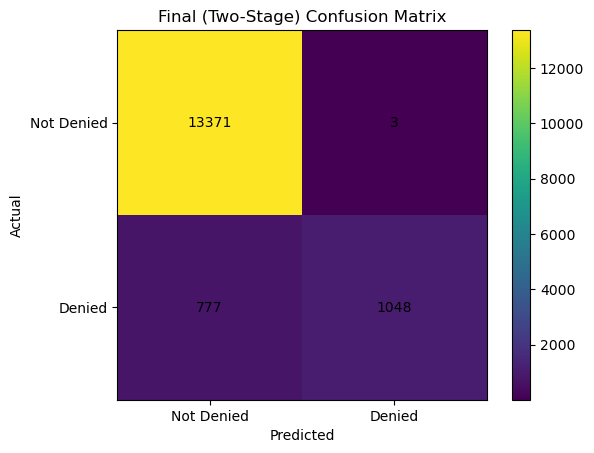

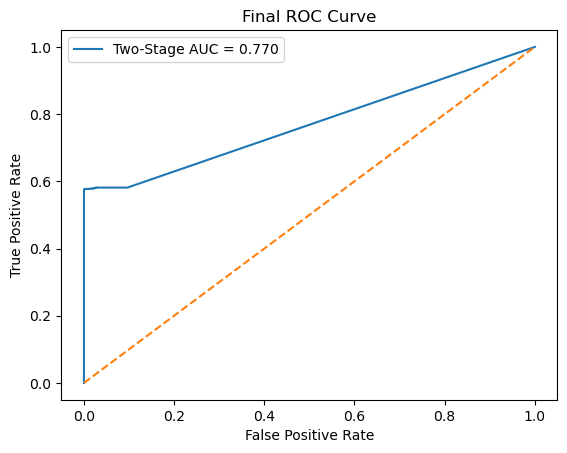

Stage 1 Passed Cases: 2351

FINAL RESULTS:
[[13371     3]
 [  777  1048]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     13374
           1       1.00      0.57      0.73      1825

    accuracy                           0.95     15199
   macro avg       0.97      0.79      0.85     15199
weighted avg       0.95      0.95      0.94     15199

ROC-AUC: 0.7704044650118509


In [23]:

probs_stage2 = stage2_model.predict_proba(X_stage2_full)[:, 1]
stage2_threshold = 0.6554356216080027  # updated threshold
stage2_preds = (probs_stage2 > stage2_threshold).astype(int)

final_preds[stage1_mask] = stage2_preds
final_probs[stage1_mask] = probs_stage2

# ============================================================
# 📊 FINAL CONFUSION MATRIX
# ============================================================

cm2 = confusion_matrix(y_valid, final_preds)
plt.figure()
plt.imshow(cm2)
plt.title("Final (Two-Stage) Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Denied","Denied"])
plt.yticks([0,1], ["Not Denied","Denied"])
for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        plt.text(j, i, cm2[i,j], ha="center", va="center")
plt.show()

# ============================================================
# 📈 FINAL ROC CURVE
# ============================================================

fpr2, tpr2, _ = roc_curve(y_valid, final_probs)
auc2 = roc_auc_score(y_valid, final_probs)
plt.figure()
plt.plot(fpr2, tpr2, label=f"Two-Stage AUC = {auc2:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 📊 FINAL METRICS
# ============================================================

print("Stage 1 Passed Cases:", stage1_mask.sum())
print("\nFINAL RESULTS:")
print(confusion_matrix(y_valid, final_preds))
print(classification_report(y_valid, final_preds))
print("ROC-AUC:", auc2)

## during training the model throwing somw warning there is no split after we checked it because of might me more zero are present the features so that i checked the model there is no such case there model was good. Then i tune the model by reducing the sub treee and depth paramater the warning was removed 

In [ ]:
#print("Best Score:", study.best_value)
#print("Best Params:", study.best_params)

#Best Score: 0.4441651434320568
#Best Params: {'n_estimators': 365, 'learning_rate': 0.011260285162166248, 'num_leaves': 54, 'max_depth': 6, 'min_child_samples': 40, 'subsample': 0.9709137025948372, 'colsample_bytree': 0.7569914852174505, 'reg_alpha': 2.9586240242195894, 'reg_lambda': 2.7612655738921585, 'scale_pos_weight': 2.9700896293454764, 'threshold': 0.5189319811483234}

In [6]:
# ============================================================
# 11. TRAIN LIGHTGBM
# ============================================================
model = LGBMClassifier(
    n_estimators=365,
    learning_rate=0.011260285162166248,
    num_leaves=54,
    max_depth=6,
    min_child_samples=40,
    subsample=0.9709137025948372,
    colsample_bytree=0.7569914852174505,
    reg_alpha=2.9586240242195894,
    reg_lambda=2.7612655738921585,
    scale_pos_weight=2.9700896293454764
)
model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_valid)[:,1]
THRESHOLD = 0.52
y_pred = (y_pred_prob>=THRESHOLD).astype(int)

print(classification_report(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid, y_pred_prob))

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

[LightGBM] [Info] Number of positive: 7300, number of negative: 53495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.646405 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151021
[LightGBM] [Info] Number of data points in the train set: 60795, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120076 -> initscore=-1.991714
[LightGBM] [Info] Start training from score -1.991714
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.93      0.95      0.94     13374
           1       0.54      0.47      0.50      1825

    accuracy                           0.89     15199
   macro avg       0.73      0.71      0.72     15199
weighted avg       0.88      0.89      0.88     15199

ROC AUC: 0.8396622971170806


In [15]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=365,
    learning_rate=0.011,
    num_leaves=64,           # increase leaves slightly
    max_depth=-1,            # remove depth restriction temporarily
    min_child_samples=20,    # lower to allow splits
    subsample=0.97,
    colsample_bytree=0.75,
    reg_alpha=0,
    reg_lambda=0,
    scale_pos_weight=2.97
)

model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_valid)[:,1]
THRESHOLD = 0.50
y_pred = (y_pred_prob >= THRESHOLD).astype(int)

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid, y_pred_prob))

[LightGBM] [Info] Number of positive: 7300, number of negative: 53495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.773033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151021
[LightGBM] [Info] Number of data points in the train set: 60795, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120076 -> initscore=-1.991714
[LightGBM] [Info] Start training from score -1.991714


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.93      0.94      0.94     13374
           1       0.53      0.49      0.51      1825

    accuracy                           0.89     15199
   macro avg       0.73      0.72      0.72     15199
weighted avg       0.88      0.89      0.88     15199

ROC AUC: 0.8404767991871367


In [14]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------
# 1️⃣ Adjusted LightGBM
# -------------------------
model = LGBMClassifier(
    n_estimators=500,         # increase trees to capture more patterns
    learning_rate=0.01,       # keep small for stability
    num_leaves=64,            # slightly more leaves
    max_depth=-1,             # no depth restriction
    min_child_samples=20,     # lower min samples to allow more splits
    subsample=0.9,            # slight randomness
    colsample_bytree=0.75,
    reg_alpha=0,              # reduce regularization to allow splits
    reg_lambda=0,
    scale_pos_weight=3.0,     # slightly increase to account for imbalance
    n_jobs=-1,                # use all cores
    random_state=42
)

# -------------------------
# 2️⃣ Train
# -------------------------
model.fit(X_train, y_train)

# -------------------------
# 3️⃣ Predict probabilities
# -------------------------
y_pred_prob = model.predict_proba(X_valid)[:,1]

# -------------------------
# 4️⃣ Adjust threshold for higher recall
# -------------------------
THRESHOLD = 0.45  # lower than 0.5 to increase recall
y_pred = (y_pred_prob >= THRESHOLD).astype(int)

# -------------------------
# 5️⃣ Evaluate
# -------------------------
print(classification_report(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid, y_pred_prob))

[LightGBM] [Info] Number of positive: 7300, number of negative: 53495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.724114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151021
[LightGBM] [Info] Number of data points in the train set: 60795, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120076 -> initscore=-1.991714
[LightGBM] [Info] Start training from score -1.991714


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.94      0.92      0.93     13374
           1       0.49      0.54      0.51      1825

    accuracy                           0.88     15199
   macro avg       0.71      0.73      0.72     15199
weighted avg       0.88      0.88      0.88     15199

ROC AUC: 0.8397384006178417


In [11]:
# Number of features with zero variance
zero_var_count = np.sum(np.std(X_train, axis=0) == 0)
print("Features with zero variance:", zero_var_count)

Features with zero variance: 0


In [ ]:
import pandas as pd

X_train_df = pd.DataFrame(X_train)  # feature_names = list of your columns
print(X_train_df.describe().T)

In [ ]:
X_train_df.describe().T